# 04 — Per-mode limits: dashboard & overlay

The multi-mode companion to [`01_limit_contour.ipynb`](01_limit_contour.ipynb),
which analyses one mode at a time: here all three sensor modes are overlaid on
one plane, at the same fiducials (0.1 TeV/$c$ threshold, 469.7 h, atmospheric
attenuation, per-mode efficiency). Live status of the remote-node scans and the 95% CL
exclusion overlay — **re-run** to refresh as caches arrive (they sync from remote-node
every few minutes).

Encoding: **hue = mode** (1 blue / 2 orange / 3 green), **shade = mediator range**
(long range dark → short range light), **line style = range** (massless solid;
others per the matplotlib linestyle gallery). Set `PLOT_MODES` below to `(1,)`
etc. to show a single mode.

In [1]:
%matplotlib inline
import colorsys
from pathlib import Path
import os as _os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import numpy as np
from luhdm import units

for _d in ("png", "svg", "pdf"):
    _os.makedirs(_d, exist_ok=True)
def save_figure(fig, name, **kw):
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)

# ---- which modes to draw (edit me: (1,), (2,3), (1,2,3), ...) ----
PLOT_MODES = (1, 2, 3)

ALL_MODES = (1, 2, 3)
BASE = {1: "#1f77b4", 2: "#ff7f0e", 3: "#2ca02c"}  # mode hue
CACHE = Path("computation_cache")
CONF = 0.95
M_PLANCK = 1.22e19

# mediator ranges ordered by physical range (long -> short); massless first.
# shade runs dark (long range) -> light (short range); style is per range.
RANGES = ["massless", "2m", "2cm", "2mm", "200um", "20um", "10um", "2um"]
LABEL = {"massless": "massless", "2m": "2 m", "2cm": "2 cm", "2mm": "2 mm",
         "200um": "200 \u00b5m", "20um": "20 \u00b5m", "10um": "10 \u00b5m", "2um": "2 \u00b5m"}
# line styles from https://matplotlib.org/stable/gallery/lines_bars_and_markers/linestyles.html
STYLE = {
    "massless": "solid",
    "2m":    (0, (5, 1)),            # densely dashed
    "2cm":   (0, (1, 1)),            # dotted
    "2mm":   (0, (3, 5, 1, 5)),      # dashdotted
    "200um": (0, (5, 5)),            # dashed
    "20um":  (0, (3, 1, 1, 1)),      # densely dashdotted
    "10um":  (0, (1, 10)),           # loosely dotted
    "2um":   (0, (3, 5, 1, 5, 1, 5)),# dashdotdotted
}
FRAC = {tag: i / (len(RANGES) - 1) for i, tag in enumerate(RANGES)}

def shade(mode, tag):
    """Shade of the mode's base hue for one range (dark=long, light=short)."""
    r, g, b = mcolors.to_rgb(BASE[mode])
    h, _, s = colorsys.rgb_to_hls(r, g, b)
    return colorsys.hls_to_rgb(h, 0.25 + 0.50 * FRAC[tag], s)

def load(mode, tag):
    f = CACHE / f"mode{mode}" / f"scan7_{tag}.npz"
    return np.load(f) if f.exists() else None

## Status grid

In [2]:
print(f"{'range':>9} | " + "  ".join(f"mode {n}" for n in ALL_MODES) + "     (excluded fraction)")
print("-" * 52)
for tag in RANGES:
    cells, present = [], 0
    for n in ALL_MODES:
        d = load(n, tag)
        if d is None:
            cells.append("  ...  ")
        else:
            present += 1
            cells.append(f" {(d['extremeness']>=CONF).mean():.3f} ")
    mark = "OK" if present == 3 else f"{present}/3"
    print(f"{tag:>9} | " + " ".join(cells) + f"   [{mark}]")

    range | mode 1  mode 2  mode 3     (excluded fraction)
----------------------------------------------------
 massless |  0.498   0.506   0.423    [OK]
       2m |  0.426   0.436   0.367    [OK]
      2cm |  0.293   0.301   0.249    [OK]
      2mm |  0.209   0.218   0.173    [OK]
    200um |  0.117   0.120   0.083    [OK]
     20um |  0.025   0.026   0.000    [OK]
     10um |  0.003   0.000   0.000    [OK]
      2um |  0.000   0.000   0.000    [OK]


## 95% CL exclusion overlay

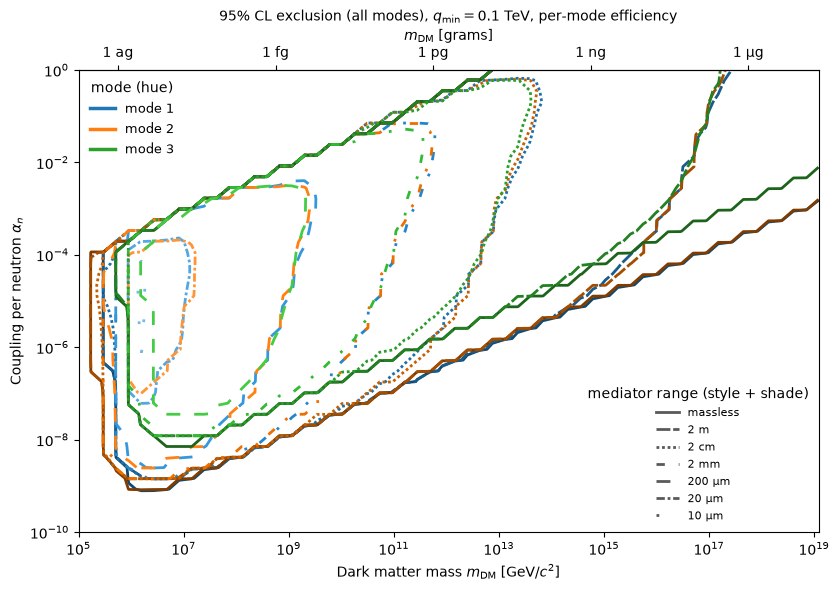

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 6))
xmin = M_PLANCK
drawn_ranges = []
for mode in PLOT_MODES:
    for tag in RANGES:
        d = load(mode, tag)
        if d is None:
            continue
        ms, al, ext = d["ms"], d["alphas_n"], d["extremeness"]
        if not (ext >= CONF).any():
            continue
        xmin = min(xmin, ms.min())
        if tag not in drawn_ranges:
            drawn_ranges.append(tag)
        ax.contour(ms, al, ext, levels=[CONF], colors=[shade(mode, tag)],
                   linestyles=[STYLE[tag]], linewidths=2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(xmin, M_PLANCK); ax.set_ylim(1e-10, 1.0)
ax.set_xlabel(r"Dark matter mass $m_{\rm DM}$ [GeV/$c^2$]")
ax.set_ylabel(r"Coupling per neutron $\alpha_n$")
# top axis in grams, labelled by SI prefix (1 GeV/c^2 = 1.78266192e-24 g)
G_PER_GEV = 1.78266192e-24
sec = ax.secondary_xaxis("top",
                         functions=(lambda x: x*G_PER_GEV, lambda g: g/G_PER_GEV))
sec.set_xlabel(r"$m_{\rm DM}$ [grams]")
_gticks = [1e-18, 1e-15, 1e-12, 1e-9, 1e-6]
_glabels = ["1 ag", "1 fg", "1 pg", "1 ng", "1 \u00b5g"]
_gmin, _gmax = xmin*G_PER_GEV, M_PLANCK*G_PER_GEV
_keep = [(t, l) for t, l in zip(_gticks, _glabels) if _gmin <= t <= _gmax]
sec.set_xticks([t for t, _ in _keep])
sec.set_xticklabels([l for _, l in _keep])
sec.xaxis.set_minor_locator(plt.NullLocator())
ttl = "mode " + "/".join(map(str, PLOT_MODES)) if len(PLOT_MODES) < 3 else "all modes"
ax.set_title(f"95% CL exclusion ({ttl}), $q_{{\\rm min}}=0.1$ TeV, per-mode efficiency",
             fontsize=10)

# two legends: hue = mode, line style+shade = range
mode_handles = [Line2D([], [], color=BASE[m], lw=2.5, label=f"mode {m}")
                for m in PLOT_MODES]
range_handles = [Line2D([], [], color="0.35", lw=2, linestyle=STYLE[t],
                        label=LABEL[t]) for t in RANGES if t in drawn_ranges]
leg1 = ax.legend(handles=mode_handles, loc="upper left", frameon=False,
                 fontsize=9, title="mode (hue)")
ax.add_artist(leg1)
if range_handles:
    ax.legend(handles=range_handles, loc="lower right", frameon=False,
              fontsize=8, title="mediator range (style + shade)")
fig.tight_layout()
tag = "modes" + "".join(map(str, PLOT_MODES))
save_figure(fig, f"04_exclusion_{tag}"); plt.show()

## Mediator range vs coupling (per mode, at each mode's best mass)

For each mode the dark-matter mass is fixed at the value giving the **widest 95% CL exclusion in the $(\alpha_n,\lambda)$ plane, prioritizing reach to the shortest mediator length** (mode 1 at $1.56\times10^{6}$ GeV, reaching 10 µm; modes 2/3 at $2.71\times10^{6}$ / $2.44\times10^{7}$ GeV). The three modes are stacked as a 3×1 panel sharing the $\lambda$ axis, each with that mode's detection efficiency folded in. The red 95% optimum-interval contour pinches off at short range where the momentum cap $\tilde q < K_1(\xi)$ drops the spectrum below threshold; the 1–20 µm zoom that follows resolves that pinch-off. Caches: `computation_cache/mode{n}/scan_lambda.npz` (and `_zoom`).

/tmp/ipykernel_187867/1283538992.py:34: RuntimeWarning: divide by zero encountered in divide
  lambda x: 1e9 / units.conv_m2pGeV(1.0) / x))


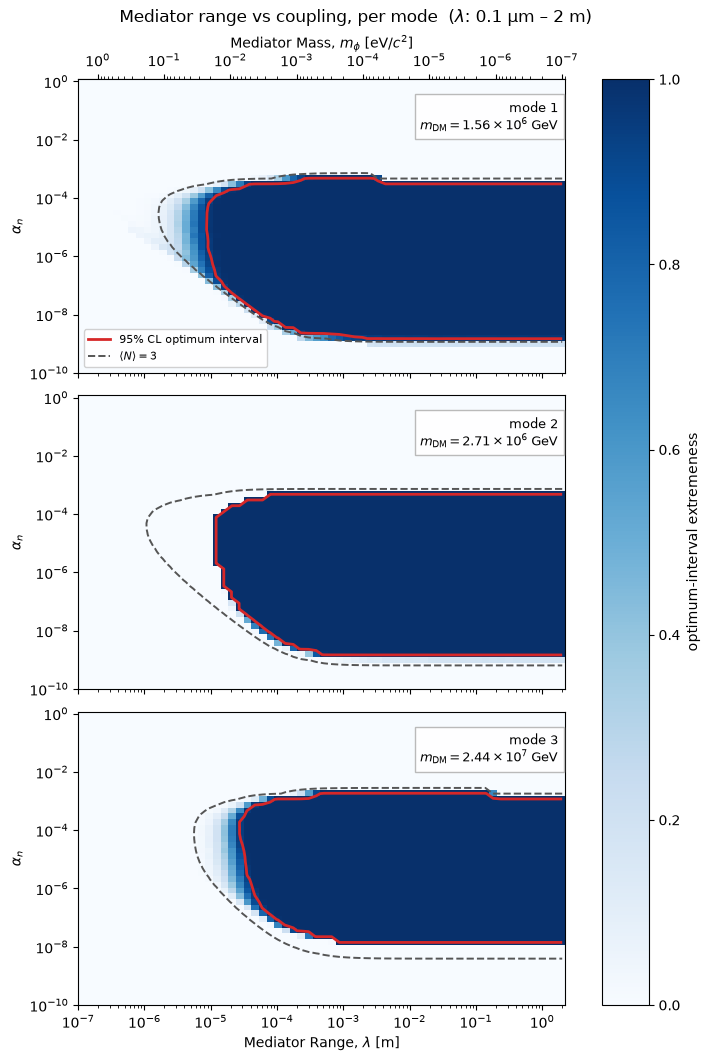

In [4]:
def load_lambda(mode, zoom=False):
    f = CACHE / f"mode{mode}" / ("scan_lambda_zoom.npz" if zoom else "scan_lambda.npz")
    return np.load(f) if f.exists() else None

def mediator_panels(zoom, figname, title):
    dats = {m: load_lambda(m, zoom) for m in ALL_MODES}
    have = [m for m in ALL_MODES if dats[m] is not None]
    if not have:
        print(f"no {'zoom ' if zoom else ''}lambda caches yet "
              "(run scripts/scan_lambda.py per mode)"); return
    fig, axes = plt.subplots(len(have), 1, figsize=(7.0, 3.5 * len(have)),
                             sharex=True, squeeze=False, constrained_layout=True)
    axes = axes[:, 0]
    mesh = None
    for row, (ax, m) in enumerate(zip(axes, have)):
        d = dats[m]
        lambs, alphas = d["lambs"], d["alphas_n"]
        p, mu, m_fixed = d["extremeness"], d["counts"], float(d["m_dm"])
        mesh = ax.pcolormesh(lambs, alphas, p, cmap="Blues", vmin=0, vmax=1,
                             shading="auto")
        ax.contour(lambs, alphas, p, levels=[CONF], colors="#d62728", linewidths=2)
        ax.contour(lambs, alphas, mu, levels=[3.0], colors="#555555",
                   linewidths=1.4, linestyles="--")
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_ylabel(r"$\alpha_n$")
        e_b = int(np.floor(np.log10(m_fixed)))
        ax.text(0.985, 0.93, f"mode {m}\n" + rf"$m_{{\rm DM}}={m_fixed / 10**e_b:.2f}"
                rf"\times10^{{{e_b}}}$ GeV", transform=ax.transAxes,
                ha="right", va="top", fontsize=9,
                bbox=dict(fc="white", ec="0.7", alpha=0.9))
        if row == 0:
            secax = ax.secondary_xaxis(
                "top", functions=(lambda x: 1e9 / units.conv_m2pGeV(x),
                                  lambda x: 1e9 / units.conv_m2pGeV(1.0) / x))
            secax.set_xlabel(r"Mediator Mass, $m_\phi$ [eV/$c^2$]")
    axes[-1].set_xlabel(r"Mediator Range, $\lambda$ [m]")
    axes[0].plot([], [], color="#d62728", lw=2, label=f"{CONF:.0%} CL optimum interval")
    axes[0].plot([], [], color="#555555", lw=1.4, ls="--", label=r"$\langle N\rangle = 3$")
    axes[0].legend(loc="lower left", fontsize=8, framealpha=0.9)
    fig.colorbar(mesh, ax=list(axes), label="optimum-interval extremeness")
    fig.suptitle(title, fontsize=12)
    save_figure(fig, figname); plt.show()

mediator_panels(False, "04_mediator_vs_coupling",
                r"Mediator range vs coupling, per mode  ($\lambda$: 0.1 µm – 2 m)")

/tmp/ipykernel_187867/1283538992.py:34: RuntimeWarning: divide by zero encountered in divide
  lambda x: 1e9 / units.conv_m2pGeV(1.0) / x))


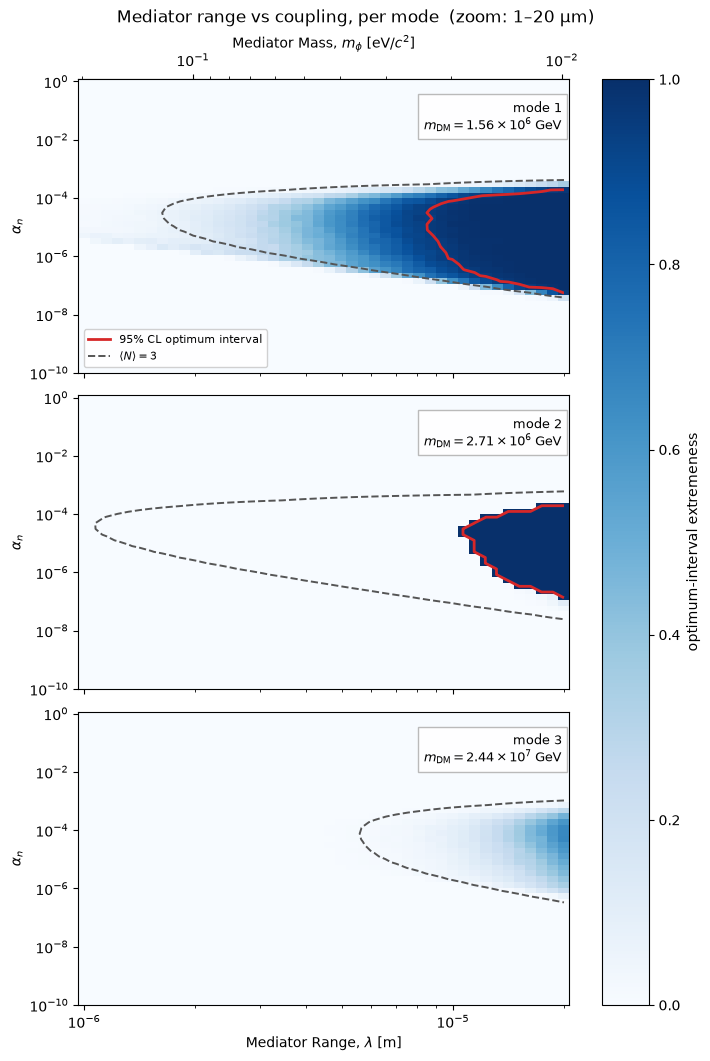

In [5]:
mediator_panels(True, "04_mediator_vs_coupling_zoom",
                r"Mediator range vs coupling, per mode  (zoom: 1–20 µm)")